Load the dataset with PySpark

In [1]:
from pyspark.sql import SparkSession
from pathlib import Path
from pyspark.sql import functions as F
import country_converter as coco
from itertools import chain

CLEANED_DATA_DIR = Path("../data/cleaned")
PROCESSED_DATA_DIR = Path("../data")

spark = SparkSession.builder.appName("profiling").config("spark.sql.ansi.enabled", "false").config("spark.driver.memory", "16g").getOrCreate()
df = spark.read.parquet(f"{PROCESSED_DATA_DIR}/4_eea_co2_emissions_from_passenger_cars-001.parquet")

last_present = df.count()
print(f"{last_present} rows present")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/06 15:37:10 WARN Utils: Your hostname, MSI-Z790, resolves to a loopback address: 127.0.1.1; using 192.168.1.124 instead (on interface enp4s0)
26/08/06 15:37:10 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/06 15:37:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


79400771 rows present


Remap column names to more easily understandable ones

In [2]:
column_mapping = {
    "Country": "geo",
    "VFN": "vehicle_family_id_number",
    "Mh": "manufacturer_name_eu_standard_denomination",
    "T": "type",
    "Va": "variant",
    "Ve": "version",
    "Mk": "make",
    "Cn": "commercial_name",
    "m (kg)": "mass_in_running_order (kg)",
    "Ewltp (g/km)": "co2_emissions_WLTP (g/km)",
    "Ft": "Motor energy",
    "Fm": "fuel_mode",
    "ec (cm3)": "engine_capacity (cm3)",
    "ep (KW)": "engine_power (KW)",
    "z (Wh/km)": "electric_energy_consumption (Wh/km)",
    "r": "registrations",
    "year": "TIME_PERIOD"
}

for old_col, new_col in column_mapping.items():
    df = df.withColumnRenamed(old_col, new_col)

Restrict temporal coverage of both datasets to the years 2014-2023.

In [3]:
df = df.filter((F.col("TIME_PERIOD") >= 2014) & (F.col("TIME_PERIOD") <= 2023))

Drop non EU countries

In [4]:
eu27_2020 = ['BE', 'BG', 'CZ', 'DK', 'DE', 'EE', 'IE', 'EL', 'ES', 'FR', 'HR', 'IT', 'CY', 'LV', 'LT', 'LU', 'HU', 'MT', 'NL', 'AT', 'PL', 'PT', 'RO', 'SI', 'SK', 'FI', 'SE']
country_dict = {code: coco.convert(names=code, to='name_short', not_found=None) for code in eu27_2020}

df = df.filter(df["geo"].isin(eu27_2020))

last_present = df.count()

In [5]:
df.filter(F.col("co2_emissions_WLTP (g/km)").isNull() & F.col("Motor energy").contains("petrol") & ~F.col("version").isNull() & F.col("commercial_name").contains("CHALLENGER SRT")).show(10)

+---+------------------------+------------------------------------------+----------+--------+--------+-----+--------------------+--------------------------+-------------------------+------------+---------+---------------------+-----------------+-----------------------------------+-----------+-------------+
|geo|vehicle_family_id_number|manufacturer_name_eu_standard_denomination|      type| variant| version| make|     commercial_name|mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|Motor energy|fuel_mode|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|TIME_PERIOD|registrations|
+---+------------------------+------------------------------------------+----------+--------+--------+-----+--------------------+--------------------------+-------------------------+------------+---------+---------------------+-----------------+-----------------------------------+-----------+-------------+
| DE|                    NULL|                                    AA-IVA|CHA

In [6]:
df.filter(~F.col("co2_emissions_WLTP (g/km)").isNull() & F.col("commercial_name").contains("CHALLENGER SRT")).show(10)

+---+------------------------+------------------------------------------+----------+--------+--------------+-----+--------------------+--------------------------+-------------------------+------------+---------+---------------------+-----------------+-----------------------------------+-----------+-------------+
|geo|vehicle_family_id_number|manufacturer_name_eu_standard_denomination|      type| variant|       version| make|     commercial_name|mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|Motor energy|fuel_mode|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|TIME_PERIOD|registrations|
+---+------------------------+------------------------------------------+----------+--------+--------------+-----+--------------------+--------------------------+-------------------------+------------+---------+---------------------+-----------------+-----------------------------------+-----------+-------------+
| DE|                    NULL|                            

Drop  N/A values

In [7]:
num_cols = [
   "mass_in_running_order (kg)", "co2_emissions_WLTP (g/km)", 
    "engine_capacity (cm3)", "engine_power (KW)", "electric_energy_consumption (Wh/km)"
]
str_cols = ["geo", "commercial_name", "Motor energy"]
all_cols = str_cols + num_cols

df = df.na.drop(subset=str_cols)
df = df.filter(df["TIME_PERIOD"] != 0)

print(f"Row count changed by: {last_present - df.count()}")
last_present = df.count()
print(f"{last_present} rows present")

Row count changed by: 163242
70727364 rows present


Drop columns we don't need

In [8]:
not_needed = ["vehicle_family_id_number", "make", "fuel_mode", "type", "version"]
df = df.drop(*not_needed)

Clean the Motor Energy column to remove all various duplicates and unnecessary values, then group the various motor energy types in the ones we intend to analyse

In [9]:
df = df.withColumn("Motor energy", 
    F.regexp_replace(F.trim(F.lower(F.col("Motor energy"))), "-", "/")
)
df.select("Motor energy").distinct().orderBy("Motor energy").rdd.map(lambda row: row[0]).collect()

['biodiesel',
 'cng',
 'diesel',
 'diesel/electric',
 'e85',
 'electric',
 'gnl',
 'hybrid/petrol/e',
 'hydrogen',
 'lpg',
 'ng',
 'ng/biomethane',
 'other',
 'petrol',
 'petrol phev',
 'petrol/electric',
 'petrol/gas',
 'unknown']

In [10]:
unnecessary = ["unknown", "other"]
df = df.filter(~df["Motor energy"].isin(unnecessary))

df = df.withColumn(
    "Motor energy",
    F.when(F.col("Motor energy") == "electric", "Electricity")
     .when(F.col("Motor energy").isin("petrol/electric", "hybrid/petrol/e", "petrol phev"), "Petrol hybrid")
     .when(F.col("Motor energy") == "diesel/electric", "Diesel hybrid")
     .when(F.col("Motor energy") == "petrol", "Petrol (excluding hybrids)")
     .when(F.col("Motor energy") == "diesel", "Diesel (excluding hybrids)")
     .otherwise("Alternative/Other") 
)

print(f"Row count changed by: {last_present - df.count()}")
last_present = df.count()
print(f"{last_present} rows present")

Row count changed by: 2213


70725151 rows present


In [11]:
df.filter(F.col("Motor energy").contains("Electricity")).show(10)

+---+------------------------------------------+------------+----------------+--------------------------+-------------------------+------------+---------------------+-----------------+-----------------------------------+-----------+-------------+
|geo|manufacturer_name_eu_standard_denomination|     variant| commercial_name|mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|Motor energy|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|TIME_PERIOD|registrations|
+---+------------------------------------------+------------+----------------+--------------------------+-------------------------+------------+---------------------+-----------------+-----------------------------------+-----------+-------------+
| DE|                                     SKODA| ACEBJAL1FX2|        ENYAQ 80|                      2111|                        0| Electricity|                 NULL|              150|                                159|       2023|            1|
| DE|       

We try filling in some of the nulls by matching on similar vehicles based on commercial name, variant and motor energy, finding the closest match based on mass and engine capacity

In [12]:
from pyspark.sql.window import Window

df_valid = df.filter(F.col("co2_emissions_WLTP (g/km)").isNotNull())
df_missing = df.filter(F.col("co2_emissions_WLTP (g/km)").isNull())

df_missing_evs = df_missing.filter(F.col("Motor energy") == "Electricity")
df_missing_non_evs = df_missing.filter(F.col("Motor energy") != "Electricity")

valid_refs = df_valid.filter(F.col("Motor energy") != "Electricity").select(
    F.col("commercial_name").alias("ref_commercial_name"),
    F.col("variant").alias("ref_variant"),
    F.col("Motor energy").alias("ref_Motor_energy"),
    F.col("mass_in_running_order (kg)").alias("ref_mass"),
    F.col("engine_capacity (cm3)").alias("ref_engine"),
    F.col("co2_emissions_WLTP (g/km)").alias("ref_co2")
).dropDuplicates()

df_missing_non_evs = df_missing_non_evs.withColumn("temp_row_id", F.monotonically_increasing_id())

joined_df = df_missing_non_evs.join(
    valid_refs,
    (df_missing_non_evs["commercial_name"] == valid_refs["ref_commercial_name"]) &
    (df_missing_non_evs["variant"] == valid_refs["ref_variant"]) &
    (df_missing_non_evs["Motor energy"] == valid_refs["ref_Motor_energy"]),
    "left"
)

joined_df = joined_df.withColumn(
    "distance",
    F.abs(F.col("mass_in_running_order (kg)") - F.col("ref_mass")) +
    F.abs(F.col("engine_capacity (cm3)") - F.col("ref_engine"))
)

window_spec = Window.partitionBy("temp_row_id").orderBy(F.col("distance").asc_nulls_last())

best_matches = joined_df.withColumn("rank", F.row_number().over(window_spec)) \
                        .filter(F.col("rank") == 1)

best_matches = best_matches.withColumn(
    "co2_emissions_WLTP (g/km)",
    F.coalesce(F.col("ref_co2"), F.col("co2_emissions_WLTP (g/km)"))
)

cols_to_drop = [
    "ref_commercial_name", "ref_variant", "ref_Motor_energy", 
    "ref_mass", "ref_engine", "ref_co2", "distance", "rank", "temp_row_id"
]
df_missing_imputed = best_matches.drop(*cols_to_drop)

df = df_valid.unionByName(df_missing_evs).unionByName(df_missing_imputed)

As a fallback, we also try filling in some of the nulls by matching on similar vehicles based on commercial name and motor energy, finding the closest match based on mass, engine capacity and engine power

In [13]:
df_valid = df.filter(F.col("co2_emissions_WLTP (g/km)").isNotNull())
df_missing = df.filter(F.col("co2_emissions_WLTP (g/km)").isNull())

df_missing_evs = df_missing.filter(F.col("Motor energy") == "Electricity")
df_missing_non_evs = df_missing.filter(F.col("Motor energy") != "Electricity")

valid_refs = df_valid.filter(F.col("Motor energy") != "Electricity").select(
    F.col("commercial_name").alias("ref_commercial_name"),
    F.col("Motor energy").alias("ref_Motor_energy"),
    F.col("mass_in_running_order (kg)").alias("ref_mass"),
    F.col("engine_capacity (cm3)").alias("ref_engine"),
    F.col("engine_power (KW)").alias("ref_power"),
    F.col("co2_emissions_WLTP (g/km)").alias("ref_co2")
).dropDuplicates()

df_missing_non_evs = df_missing_non_evs.withColumn("temp_row_id", F.monotonically_increasing_id())

joined_df = df_missing_non_evs.join(
    valid_refs,
    (df_missing_non_evs["commercial_name"] == valid_refs["ref_commercial_name"]) &
    (df_missing_non_evs["Motor energy"] == valid_refs["ref_Motor_energy"]),
    "left"
)

joined_df = joined_df.withColumn(
    "distance",
    F.abs(F.col("mass_in_running_order (kg)") - F.col("ref_mass")) +
    (F.abs(F.col("engine_capacity (cm3)") - F.col("ref_engine")) * 2) +
    (F.abs(F.col("engine_power (KW)") - F.col("ref_power")) * 5)
)

window_spec = Window.partitionBy("temp_row_id").orderBy(F.col("distance").asc_nulls_last())

best_matches = joined_df.withColumn("rank", F.row_number().over(window_spec)) \
                        .filter(F.col("rank") == 1)

best_matches = best_matches.withColumn(
    "co2_emissions_WLTP (g/km)",
    F.coalesce(F.col("ref_co2"), F.col("co2_emissions_WLTP (g/km)"))
)

cols_to_drop = [
    "ref_commercial_name", "ref_Motor_energy", "ref_mass", 
    "ref_engine", "ref_power", "ref_co2", "distance", "rank", "temp_row_id"
]
df_imputed_p2 = best_matches.drop(*cols_to_drop)

df = df_valid.unionByName(df_missing_evs).unionByName(df_imputed_p2)

Clean the manufacturer_name_eu_standard_denomination column, removing unnecessary values and reducing duplicates

In [14]:
df = df.filter(~F.col("manufacturer_name_eu_standard_denomination").isin("DUPLICATE", "OUT OF SCOPE", "UNKNOWN", "duplicate", "unknown"))

name_map = {
    "AUDI HUNGARIA": "AUDI AG",
    "AUDI SPORT": "AUDI AG",
    "BEE": "BEE BEE",
    "BLUECAR ITALY": "BLUECAR",
    "BMW GMBH": "BMW AG",
    "DONGFENG LIUZHOU": "DONGFENG",
    "DONGFENG MOTOR": "DONGFENG",
    "DONKEVOORT": "DONKERVOORT",
    "DR MOTOR": "DR AUTOMOBILES",
    "Duplicate": "DUPLICATE",
    "FORD INDIA": "FORD MOTOR COMPANY",
    "FORD MOTOR AUSTRALIA": "FORD MOTOR COMPANY",
    "FORD WERKE GMBH": "FORD MOTOR COMPANY",
    "Ford Motor Company": "FORD MOTOR COMPANY",
    "GENERAL MOTORS COMPANY": "GENERAL MOTORS",
    "GENERAL MOTORS HOLDINGS": "GENERAL MOTORS",
    "GM ITALIA": "GENERAL MOTORS",
    "GM KOREA": "GENERAL MOTORS",
    "GM KOREA": "GENERAL MOTORS",
    "HONDA CHINA": "HONDA",
    "HONDA MOTOR CO": "HONDA",
    "HONDA THAILAND": "HONDA",
    "HONDA TURKIYE": "HONDA",
    "HONDA UK": "HONDA",
    "HYUNDAI ASSAN": "HYUNDAI",
    "HYUNDAI ASSAN": "HYUNDAI",
    "HYUNDAI CZECH": "HYUNDAI",
    "HYUNDAI CZECH": "HYUNDAI",
    "HYUNDAI EUROPE": "HYUNDAI",
    "HYUNDAI INDIA": "HYUNDAI",
    "JIANGXI JIANGLING": "JIANGLING MOTOR",
    "KIA SLOVAKIA": "KIA",
    "KIA SLOVAKIA": "KIA",
    "LADA FRANCE": "LADA",
    "LANZHOU ZHIDOU": "LANZHOU",
    "MAGYAR SUZUKI": "SUZUKI MOTOR CORPORATION",
    "MARUTI SUZUKI": "SUZUKI MOTOR CORPORATION",
    "MAZDA EUROPE": "MAZDA",
    "MERCEDES AMG": "MERCEDES-BENZ AG",
    "MERCEDES-AMG": "MERCEDES-BENZ AG",
    "NISSAN AUTOMOTIVE EUROPE": "NISSAN",
    "OPEL AUTOMOBILE": "OPEL",
    "QUATTRO": "AUDI AG",
    "RADICAL MOTOSPORT": "RADICAL MOTORSPORT",
    "ROLLS-ROYCE": "ROLLS ROYCE",
    "SAIC MAXUS": "SAIC MOTOR CORPORATION",
    "SAIC MOTOR": "SAIC MOTOR CORPORATION",
    "STELLANTIS EUROPE": "STELLANTIS AUTO",
    "SUZUKI THAILAND": "SUZUKI MOTOR CORPORATION",
    "TOYOTA MOTOR CORPORATION": "TOYOTA",
    "WUHAN LOTUS": "LOTUS"
}

df = df.replace(name_map, subset=["manufacturer_name_eu_standard_denomination"])
print(f"Row count changed by: {last_present - df.count()}")
last_present = df.count()
print(f"{last_present} rows present")

Row count changed by: 53735


70671416 rows present


Fill in missing engine capacity

In [ ]:
df_valid = df.filter(F.col("engine_capacity (cm3)").isNotNull())
df_missing = df.filter(F.col("engine_capacity (cm3)").isNull())

df_missing_evs = df_missing.filter(F.col("Motor energy") == "Electricity")
df_missing_non_evs = df_missing.filter(F.col("Motor energy") != "Electricity")

valid_refs = df_valid.filter(F.col("Motor energy") != "Electricity").groupBy(
    F.col("commercial_name").alias("ref_commercial_name"),
    F.col("variant").alias("ref_variant"),
    F.col("Motor energy").alias("ref_Motor_energy"),
    F.col("mass_in_running_order (kg)").alias("ref_mass"),
    F.col("co2_emissions_WLTP (g/km)").alias("ref_co2")
).agg(
    F.round(F.avg("engine_capacity (cm3)"), 0).alias("ref_engine")
)

df_missing_non_evs = df_missing_non_evs.withColumn("temp_row_id", F.monotonically_increasing_id())

joined_df = df_missing_non_evs.join(
    F.broadcast(valid_refs),
    (df_missing_non_evs["commercial_name"] == valid_refs["ref_commercial_name"]) &
    (df_missing_non_evs["variant"] == valid_refs["ref_variant"]) &
    (df_missing_non_evs["Motor energy"] == valid_refs["ref_Motor_energy"]),
    "left"
)

joined_df = joined_df.withColumn(
    "distance",
    F.abs(F.col("mass_in_running_order (kg)") - F.col("ref_mass")) +
    F.abs(F.col("co2_emissions_WLTP (g/km)") - F.col("ref_co2"))
)

window_spec = Window.partitionBy("temp_row_id").orderBy(F.col("distance").asc_nulls_last())

best_matches = joined_df.withColumn("rank", F.row_number().over(window_spec)) \
                        .filter(F.col("rank") == 1)

best_matches = best_matches.withColumn(
    "engine_capacity (cm3)",
    F.coalesce(F.col("ref_engine"), F.col("engine_capacity (cm3)"))
)

cols_to_drop = [
    "ref_commercial_name", "ref_variant", "ref_Motor_energy", 
    "ref_mass", "ref_co2", "ref_engine", "distance", "rank", "temp_row_id"
]
df_missing_imputed = best_matches.drop(*cols_to_drop)

df = df_valid.unionByName(df_missing_evs).unionByName(df_missing_imputed)

Fill in missing engine power

In [ ]:
df_valid = df.filter(F.col("engine_power (KW)").isNotNull())
df_missing = df.filter(F.col("engine_power (KW)").isNull())

valid_refs = df_valid.groupBy(
    F.col("commercial_name").alias("ref_commercial_name"),
    F.col("variant").alias("ref_variant"),
    F.col("Motor energy").alias("ref_Motor_energy"),
    F.col("mass_in_running_order (kg)").alias("ref_mass")
).agg(
    F.round(F.avg("engine_power (KW)"), 1).alias("ref_power")
)

df_missing = df_missing.withColumn("temp_row_id", F.monotonically_increasing_id())

joined_df = df_missing.join(
    F.broadcast(valid_refs),
    (df_missing["commercial_name"] == valid_refs["ref_commercial_name"]) &
    (df_missing["variant"] == valid_refs["ref_variant"]) &
    (df_missing["Motor energy"] == valid_refs["ref_Motor_energy"]),
    "left"
)

joined_df = joined_df.withColumn(
    "distance",
    F.abs(F.col("mass_in_running_order (kg)") - F.col("ref_mass"))
)

window_spec = Window.partitionBy("temp_row_id").orderBy(F.col("distance").asc_nulls_last())

best_matches = joined_df.withColumn("rank", F.row_number().over(window_spec)) \
                        .filter(F.col("rank") == 1)

best_matches = best_matches.withColumn(
    "engine_power (KW)",
    F.coalesce(F.col("ref_power"), F.col("engine_power (KW)"))
)

cols_to_drop = [
    "ref_commercial_name", "ref_variant", "ref_Motor_energy", 
    "ref_mass", "ref_power", "distance", "rank", "temp_row_id"
]
df_missing_imputed = best_matches.drop(*cols_to_drop)

df = df_valid.unionByName(df_missing_imputed)

Fill in missing electric energy consumption

In [ ]:
electrified_categories = ["Electricity", "Petrol hybrid", "Diesel hybrid"]

df_valid = df.filter(F.col("electric_energy_consumption (Wh/km)").isNotNull())
df_missing = df.filter(F.col("electric_energy_consumption (Wh/km)").isNull())

df_missing_electrified = df_missing.filter(F.col("Motor energy").isin(electrified_categories))
df_missing_ice = df_missing.filter(~F.col("Motor energy").isin(electrified_categories))

valid_refs = df_valid.filter(F.col("Motor energy").isin(electrified_categories)).groupBy(
    F.col("commercial_name").alias("ref_commercial_name"),
    F.col("variant").alias("ref_variant"),
    F.col("Motor energy").alias("ref_Motor_energy"),
    F.col("mass_in_running_order (kg)").alias("ref_mass"),
    F.col("engine_power (KW)").alias("ref_power")
).agg(
    F.round(F.avg("electric_energy_consumption (Wh/km)"), 1).alias("ref_consumption")
)

df_missing_electrified = df_missing_electrified.withColumn("temp_row_id", F.monotonically_increasing_id())

joined_df = df_missing_electrified.join(
    F.broadcast(valid_refs),
    (df_missing_electrified["commercial_name"] == valid_refs["ref_commercial_name"]) &
    (df_missing_electrified["variant"] == valid_refs["ref_variant"]) &
    (df_missing_electrified["Motor energy"] == valid_refs["ref_Motor_energy"]),
    "left"
)

joined_df = joined_df.withColumn(
    "distance",
    F.abs(F.col("mass_in_running_order (kg)") - F.col("ref_mass")) +
    F.abs(F.col("engine_power (KW)") - F.col("ref_power"))
)

window_spec = Window.partitionBy("temp_row_id").orderBy(F.col("distance").asc_nulls_last())

best_matches = joined_df.withColumn("rank", F.row_number().over(window_spec)) \
                        .filter(F.col("rank") == 1)

best_matches = best_matches.withColumn(
    "electric_energy_consumption (Wh/km)",
    F.coalesce(F.col("ref_consumption"), F.col("electric_energy_consumption (Wh/km)"))
)

cols_to_drop = [
    "ref_commercial_name", "ref_variant", "ref_Motor_energy", 
    "ref_mass", "ref_power", "ref_consumption", "distance", "rank", "temp_row_id"
]
df_missing_imputed = best_matches.drop(*cols_to_drop)

df = df_valid.unionByName(df_missing_ice).unionByName(df_missing_imputed)

Aggregate registrations by merging rows that are now duplicated, construct a new standard geopoliticaly entity column like with the other datasets, then finally reorder columns and write the results to disk

In [18]:
grouping_columns = [col for col in df.columns if col != "registrations"]
df = df.groupBy(*grouping_columns) \
               .agg(F.sum("registrations").alias("registrations"))

mapping_expr = F.create_map([F.lit(x) for x in chain(*country_dict.items())])
df = df.withColumn("Geopolitical entity (reporting)", mapping_expr[F.col("geo")])

df = df.withColumn("registrations", F.col("registrations").cast("integer"))

df = df.select(
    "geo",
    "Geopolitical entity (reporting)",
    "TIME_PERIOD",
    "registrations",
    "manufacturer_name_eu_standard_denomination",
    "commercial_name",
    "variant",
    "Motor energy",
    "mass_in_running_order (kg)",
    "co2_emissions_WLTP (g/km)",
    "engine_capacity (cm3)",
    "engine_power (KW)",
    "electric_energy_consumption (Wh/km)"
)

print(f"Row count changed by: {last_present - df.count()}")
last_present = df.count()
print(f"{last_present} rows present")

26/08/06 16:18:25 WARN DAGScheduler: Broadcasting large task binary with size 1145.0 KiB
26/08/06 16:19:16 WARN DAGScheduler: Broadcasting large task binary with size 1285.2 KiB
26/08/06 16:20:09 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 16:20:10 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 16:23:09 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 16:23:41 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 16:24:15 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 16:24:15 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 16:24:59 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
26/08/06 16:26:30 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


Row count changed by: 68477190


26/08/06 16:54:27 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/06 16:55:19 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 16:55:50 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 16:56:36 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 16:57:18 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 16:58:02 WARN DAGScheduler: Broadcasting large task binary with size 1145.0 KiB
26/08/06 16:58:22 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 16:59:02 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 16:59:49 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
26/08/06 17:01:22 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


2194200 rows present


# FROM HERE

> Probably zeros / null values need to be resolved before aggregation so we also have more columns to find the correct values to impute. 

> If not we can try to search for the same car 'commercial_name' and 'manufacturer_name_eu_standard_denomination' and other categories that enable to distinguish univoquely the car we can try to impute the missing values!

Convert numeric columns to the correct data type.

> TODO: Check if 'int' is fine or we need to use 'double'!

In [ ]:
df = df.withColumn("mass_in_running_order (kg)", F.col("mass_in_running_order (kg)").cast("float")) \
       .withColumn("co2_emissions_WLTP (g/km)", F.col("co2_emissions_WLTP (g/km)").cast("float")) \
       .withColumn("engine_capacity (cm3)", F.col("engine_capacity (cm3)").cast("float")) \
       .withColumn("engine_power (KW)", F.col("engine_power (KW)").cast("float")) \
       .withColumn("electric_energy_consumption (Wh/km)", F.col("electric_energy_consumption (Wh/km)").cast("float"))

In [20]:
df.show(10, truncate=False)

26/08/06 17:28:39 WARN DAGScheduler: Broadcasting large task binary with size 1152.6 KiB
26/08/06 17:31:35 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/06 17:32:09 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 17:32:10 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 17:32:10 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 17:32:42 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 17:33:48 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 17:33:49 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 17:34:34 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/08/06 17:36:04 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB


+---+-------------------------------+-----------+-------------+------------------------------------------+----------------------+-------+-------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|registrations|manufacturer_name_eu_standard_denomination|commercial_name       |variant|Motor energy |mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|
+---+-------------------------------+-----------+-------------+------------------------------------------+----------------------+-------+-------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|DE |Germany                        |2023       |543          |BMW AG                                    |X3 XDRIVE 30E         |61DP   |Petrol hybrid|2065  

Check zeros / null values in the 'co2_emissions_WLTP (g/km)' column

> Most zeros are associated with 'Motor energy' = 'Electricity', some with 'Motor energy' = 'Alternative/Other'. If not needed for the dashboard we can decide wether to drop the 'Alternative/Other' category in the dataset.

> TODO: null values need to be imputed there are lots!

In [21]:
df.filter(F.col("co2_emissions_WLTP (g/km)") == 0).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

26/08/06 18:03:22 WARN DAGScheduler: Broadcasting large task binary with size 1145.0 KiB
26/08/06 18:04:09 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/06 18:04:59 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 18:05:01 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 18:07:47 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 18:08:16 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 18:08:48 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 18:08:48 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 18:09:31 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
26/08/06 18:10:39 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/08/06 18:10:39 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB


+-----------------+-----+
|     Motor energy|count|
+-----------------+-----+
|      Electricity|85144|
|Alternative/Other|  157|
+-----------------+-----+



In [22]:
df.filter(F.col("co2_emissions_WLTP (g/km)").isNull()).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

26/08/06 18:40:30 WARN DAGScheduler: Broadcasting large task binary with size 1145.0 KiB
26/08/06 18:41:06 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/06 18:41:51 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 18:41:52 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 18:41:52 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 18:42:22 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 18:43:26 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 18:43:27 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 18:44:10 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
26/08/06 18:45:15 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/08/06 18:45:15 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


+--------------------+-----+
|        Motor energy|count|
+--------------------+-----+
|Diesel (excluding...|60747|
|Petrol (excluding...|46748|
|         Electricity| 4274|
|       Petrol hybrid| 2229|
|   Alternative/Other| 2045|
|       Diesel hybrid|  563|
+--------------------+-----+



In [23]:
df.filter(F.col("co2_emissions_WLTP (g/km)").isNull()).groupBy("manufacturer_name_eu_standard_denomination").count().orderBy(F.col("count").desc()).show(truncate=False)

26/08/06 19:12:25 WARN DAGScheduler: Broadcasting large task binary with size 1145.0 KiB
26/08/06 19:15:58 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/06 19:16:32 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 19:16:33 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 19:16:33 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 19:17:04 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 19:18:12 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 19:18:12 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 19:18:58 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
26/08/06 19:20:01 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/08/06 19:20:02 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


+------------------------------------------+-----+
|manufacturer_name_eu_standard_denomination|count|
+------------------------------------------+-----+
|DAIMLER AG                                |14171|
|BMW AG                                    |12831|
|OPEL                                      |7928 |
|TOYOTA                                    |7800 |
|KIA                                       |7060 |
|AA-IVA                                    |5992 |
|NISSAN                                    |4389 |
|VOLKSWAGEN                                |4284 |
|AUDI AG                                   |4247 |
|JAGUAR LAND ROVER LIMITED                 |4241 |
|FORD MOTOR COMPANY                        |4055 |
|SKODA                                     |3969 |
|AUTOMOBILES CITROEN                       |3718 |
|VOLVO                                     |3476 |
|AUTOMOBILES PEUGEOT                       |3448 |
|HYUNDAI                                   |2662 |
|GENERAL MOTORS                

Check zeros / null values in the 'engine_capacity (cm3)' column

> No zeros found!

> TODO: null values, apart from the 'Motor energy' = 'Electricity' category,are also in some rows with 'Motor energy' in 'Petrol' and 'Diesel' categories!

In [24]:
df.filter(F.col("engine_capacity (cm3)") == 0).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

26/08/06 19:48:24 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/06 19:49:13 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 19:49:14 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 19:49:54 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 19:50:34 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 19:51:25 WARN DAGScheduler: Broadcasting large task binary with size 1145.0 KiB
26/08/06 19:51:43 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 19:52:26 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 19:53:11 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB


+------------+-----+
|Motor energy|count|
+------------+-----+
+------------+-----+



In [25]:
df.filter(F.col("engine_capacity (cm3)").isNull()).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

26/08/06 20:21:47 WARN DAGScheduler: Broadcasting large task binary with size 1145.0 KiB
26/08/06 20:23:43 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/06 20:24:20 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 20:24:21 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 20:26:09 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 20:26:39 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 20:27:11 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 20:27:12 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 20:27:55 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/08/06 20:29:04 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/08/06 20:29:05 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB


+--------------------+-----+
|        Motor energy|count|
+--------------------+-----+
|         Electricity|89406|
|Petrol (excluding...|  561|
|Diesel (excluding...|  421|
|   Alternative/Other|  176|
|       Petrol hybrid|   52|
+--------------------+-----+



In [26]:
df.filter(F.col("engine_capacity (cm3)").isNull()).filter(F.col("Motor energy") != "Electricity").show()

26/08/06 20:57:10 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/06 20:58:00 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 20:59:19 WARN DAGScheduler: Broadcasting large task binary with size 1152.6 KiB
26/08/06 20:59:39 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 21:01:39 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 21:02:08 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 21:02:40 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 21:02:40 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 21:03:25 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
26/08/06 21:04:28 WARN DAGScheduler: Broadcasting large task binary with size 4.5 MiB


+---+-------------------------------+-----------+-------------+------------------------------------------+--------------------+--------+--------------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|registrations|manufacturer_name_eu_standard_denomination|     commercial_name| variant|        Motor energy|mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|
+---+-------------------------------+-----------+-------------+------------------------------------------+--------------------+--------+--------------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
| DK|                        Denmark|       2023|            1|                                   BENTLEY|         FLYING SPUR|  B4CYDD|   

Check zeros / null values in the 'engine_power (KW)' column

> Few zeros associated with 'Motor energy' = 'Petrol (excluding hybrid)' and 'Motor energy' = 'Diesel (excluding hybrid)'. Are all from 'BMW AG'!

>

In [27]:
df.filter(F.col("engine_power (KW)") == 0).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

26/08/06 21:31:51 WARN DAGScheduler: Broadcasting large task binary with size 1145.0 KiB
26/08/06 21:34:47 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/06 21:35:20 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 21:35:21 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 21:35:21 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 21:35:52 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 21:36:58 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 21:36:58 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 21:37:43 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/08/06 21:38:47 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/08/06 21:38:48 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB


+--------------------+-----+
|        Motor energy|count|
+--------------------+-----+
|Diesel (excluding...|   17|
|Petrol (excluding...|   12|
+--------------------+-----+



In [28]:
df.filter(F.col("engine_power (KW)") == 0).show(30, truncate=False)

26/08/06 22:07:49 WARN DAGScheduler: Broadcasting large task binary with size 1152.6 KiB
26/08/06 22:09:29 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/06 22:10:04 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 22:10:04 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 22:10:05 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 22:10:37 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 22:11:45 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 22:11:45 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 22:12:30 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/08/06 22:13:35 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB


+---+-------------------------------+-----------+-------------+------------------------------------------+---------------+-------+--------------------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|registrations|manufacturer_name_eu_standard_denomination|commercial_name|variant|Motor energy              |mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|
+---+-------------------------------+-----------+-------------+------------------------------------------+---------------+-------+--------------------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|ES |Spain                          |2014       |15           |BMW AG                                    |X5 XDRIVE40D   |KS61   |Diesel (e

In [29]:
df.filter(F.col("engine_power (KW)").isNull()).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

26/08/06 22:41:29 WARN DAGScheduler: Broadcasting large task binary with size 1145.0 KiB
26/08/06 22:41:30 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/06 22:42:40 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 22:42:41 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 22:45:26 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 22:45:56 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 22:46:27 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 22:46:27 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 22:47:06 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/08/06 22:48:11 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/08/06 22:48:12 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB


+--------------------+-----+
|        Motor energy|count|
+--------------------+-----+
|Diesel (excluding...| 9801|
|Petrol (excluding...| 6866|
|         Electricity| 3369|
|       Petrol hybrid|  459|
|   Alternative/Other|   87|
|       Diesel hybrid|    9|
+--------------------+-----+



Check zeros / null values in the 'electric_energy_consumption (Wh/km)' column

> TODO: categories that should not have values have them, and categories that should have values don't have them. Need to check if we can do something about this!

In [30]:
df.filter(F.col("electric_energy_consumption (Wh/km)") == 0).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

26/08/06 23:16:41 WARN DAGScheduler: Broadcasting large task binary with size 1145.0 KiB
26/08/06 23:19:17 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/06 23:19:51 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 23:19:52 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 23:19:52 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 23:20:23 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 23:21:27 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 23:21:27 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 23:22:08 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB


+------------+-----+
|Motor energy|count|
+------------+-----+
+------------+-----+



In [31]:
df.filter(F.col("electric_energy_consumption (Wh/km)") != 0).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

26/08/06 23:51:05 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/06 23:52:12 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/06 23:52:44 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/06 23:53:24 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/06 23:54:06 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/06 23:54:49 WARN DAGScheduler: Broadcasting large task binary with size 1145.0 KiB
26/08/06 23:55:06 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/06 23:55:40 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/06 23:56:18 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/08/06 23:57:26 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/08/06 23:57:27 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB


+--------------------+------+
|        Motor energy| count|
+--------------------+------+
|       Petrol hybrid|115651|
|         Electricity| 86548|
|       Diesel hybrid| 12356|
|Petrol (excluding...|   663|
|Diesel (excluding...|   212|
|   Alternative/Other|     8|
+--------------------+------+



In [32]:
df.filter(F.col("electric_energy_consumption (Wh/km)").isNull()).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

26/08/07 00:25:12 WARN DAGScheduler: Broadcasting large task binary with size 1145.0 KiB
26/08/07 00:28:42 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/07 00:29:15 WARN DAGScheduler: Broadcasting large task binary with size 1167.4 KiB
26/08/07 00:29:16 WARN DAGScheduler: Broadcasting large task binary with size 1979.0 KiB
26/08/07 00:29:16 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/07 00:29:48 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/07 00:30:49 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/07 00:30:49 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/07 00:31:26 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/08/07 00:32:40 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/08/07 00:32:42 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB


+--------------------+------+
|        Motor energy| count|
+--------------------+------+
|Petrol (excluding...|988317|
|Diesel (excluding...|961307|
|   Alternative/Other| 19660|
|       Petrol hybrid|  4326|
|         Electricity|  2870|
|       Diesel hybrid|  2305|
+--------------------+------+



Save the cleaned dataset to disk in parquet format.

In [33]:
df.write.mode("overwrite") \
    .option("compression", "gzip") \
    .parquet(f"{CLEANED_DATA_DIR}/4c_eea_co2_emissions_from_passenger_cars-001.parquet")

26/08/07 01:01:45 WARN DAGScheduler: Broadcasting large task binary with size 1285.2 KiB
26/08/07 01:02:28 WARN DAGScheduler: Broadcasting large task binary with size 1166.8 KiB
26/08/07 01:02:29 WARN DAGScheduler: Broadcasting large task binary with size 1978.2 KiB
26/08/07 01:03:04 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/07 01:03:38 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/07 01:05:10 WARN DAGScheduler: Broadcasting large task binary with size 1152.3 KiB
26/08/07 01:05:26 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/08/07 01:06:00 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/08/07 01:06:38 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/08/07 01:08:10 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB


26/08/07 01:50:07 WARN DAGScheduler: Broadcasting large task binary with size 1285.7 KiB
26/08/07 01:50:07 WARN DAGScheduler: Broadcasting large task binary with size 1274.1 KiB
26/08/07 01:50:52 WARN DAGScheduler: Broadcasting large task binary with size 1168.3 KiB
26/08/07 01:51:29 WARN DAGScheduler: Broadcasting large task binary with size 1993.2 KiB
26/08/07 01:51:30 WARN DAGScheduler: Broadcasting large task binary with size 1160.6 KiB
26/08/07 01:51:58 WARN DAGScheduler: Broadcasting large task binary with size 1973.3 KiB
26/08/07 01:51:59 WARN DAGScheduler: Broadcasting large task binary with size 1976.6 KiB
26/08/07 01:54:01 WARN DAGScheduler: Broadcasting large task binary with size 1979.8 KiB
26/08/07 01:54:29 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/07 01:55:00 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/08/07 01:55:00 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
26/08/07 01:55:34 WARN DAGSche

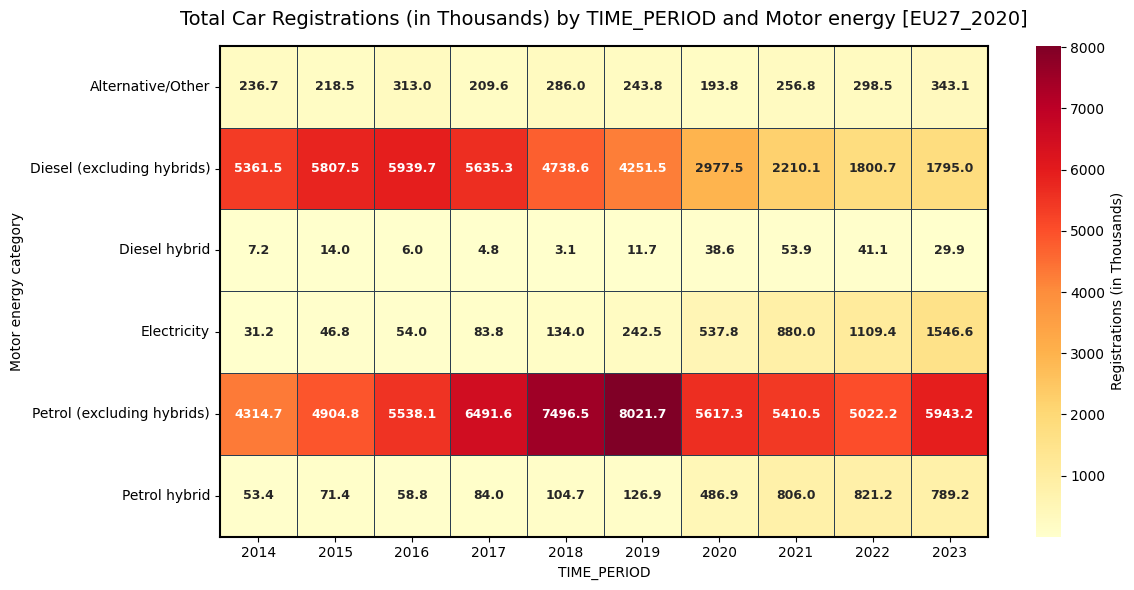

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pivoted_df = (
    df.groupBy("Motor energy")
      .pivot("TIME_PERIOD")
      .agg(F.round(F.sum("registrations") / 1000, 1))
      .fillna(0)
      .orderBy("Motor energy")
)

raw_rows = pivoted_df.collect()
columns = pivoted_df.columns
years = sorted([c for c in columns if c != "Motor energy"])

matrix_dict = {
    r["Motor energy"]: [r[y] for y in years]
    for r in raw_rows
}

heatmap_data = pd.DataFrame.from_dict(matrix_dict, orient="index", columns=years)

plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="",
    annot_kws={"weight": "bold", "size": 9},
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="#2c3e50",
    cbar_kws={'label': 'Registrations (in Thousands)'}
)

# Heatmap border
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

plt.title("Total Car Registrations (in Thousands) by TIME_PERIOD and Motor energy [EU27_2020]", fontsize=14, pad=15)
plt.xlabel("TIME_PERIOD")
plt.ylabel("Motor energy category")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("img/powertrain_year_heatmap.png", dpi=300)
plt.show()